In [39]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

PLOTS_ROOT = Path.cwd() / "data_exploration"
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

from multigraph_generation import TASKS
print(TASKS)

df = pd.read_csv("test_generation_parameters.csv")

['cycle2', 'cycle3', 'cycle4', 'cycle5']


In [3]:
tasks = set()
for col in df.columns:
    if col.startswith("train_") and col.endswith("_pos_rate"):
        tasks.add(col[len("train_") : -len("_pos_rate")])
    if col.startswith("train_") and col.endswith("_motif_count"):
        tasks.add(col[len("train_") : -len("_motif_count")])
tasks = sorted(tasks)
print(tasks == TASKS)

True


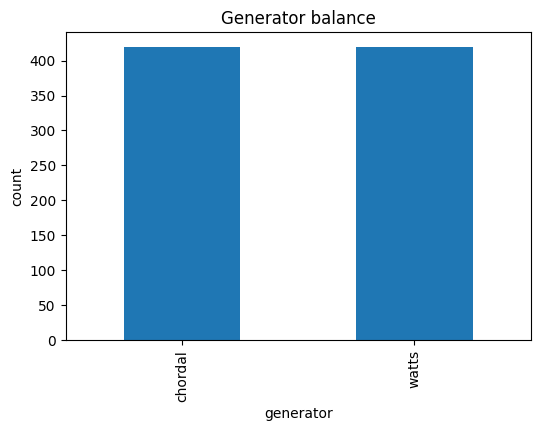

In [4]:
vc = df["type"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
vc.plot(kind="bar")
plt.title("Generator balance")
plt.xlabel("generator")
plt.ylabel("count")
plt.show()

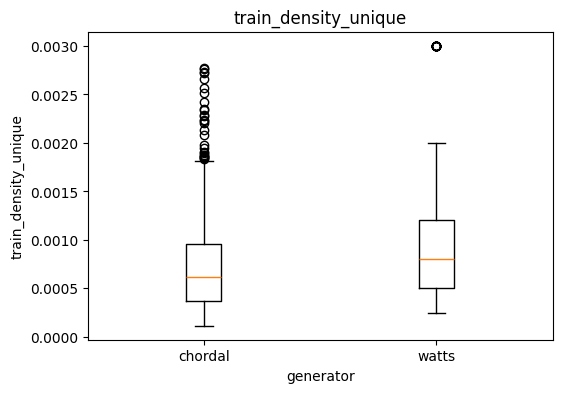

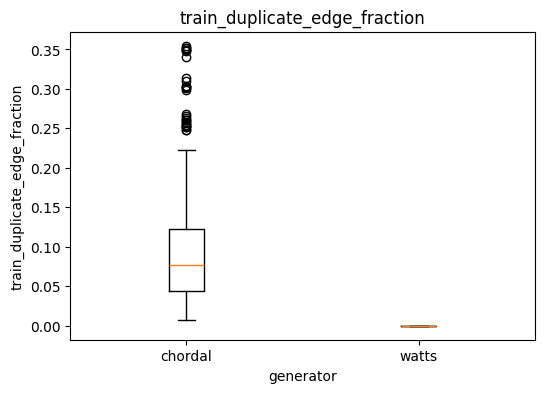

In [5]:
cols = [c for c in ["train_density_unique", "train_duplicate_edge_fraction"] if c in df.columns]
for col in cols:
    plt.figure(figsize=(6, 4))
    data = [df.loc[df["type"] == g, col].dropna().values for g in sorted(df["type"].unique())]
    labels = sorted(df["type"].unique())
    plt.boxplot(data, tick_labels=labels)
    plt.title(col)
    plt.xlabel("generator")
    plt.ylabel(col)

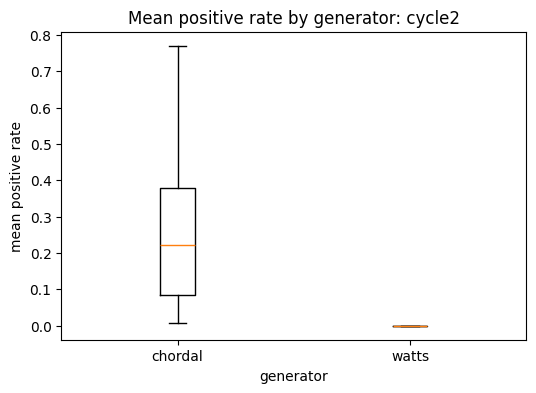

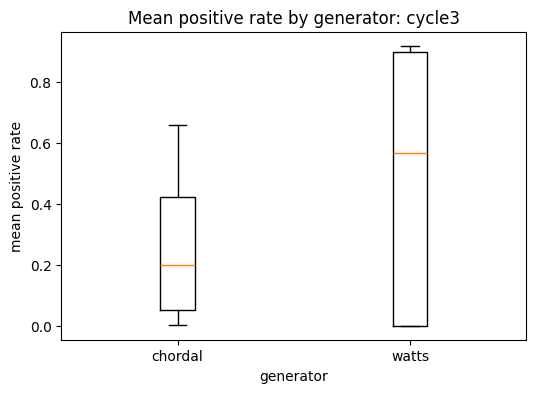

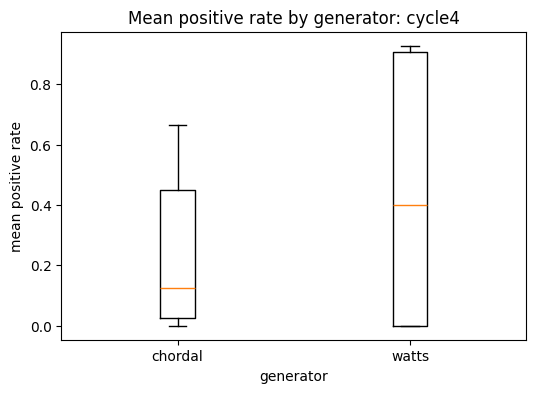

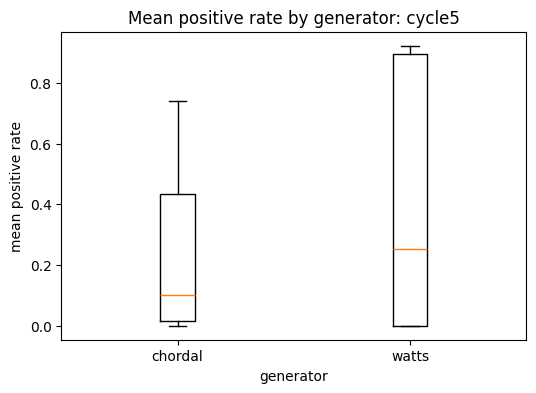

In [7]:
for task in tasks:
    if f"{task}_pos_rate_mean" in df.columns:
        col = f"{task}_pos_rate_mean"
        ylabel = "mean positive rate"
        title = f"Mean positive rate by generator: {task}"
    elif f"train_{task}_motif_count" in df.columns:
        col = f"train_{task}_motif_count"
        ylabel = "train motif count"
        title = f"Train motif count by generator: {task}"
    else:
        continue
    plt.figure(figsize=(6, 4))
    data = [df.loc[df["type"] == g, col].dropna().values for g in sorted(df["type"].unique())]
    labels = sorted(df["type"].unique())
    plt.boxplot(data, tick_labels=labels)
    plt.title(title)
    plt.xlabel("generator")
    plt.ylabel(ylabel)

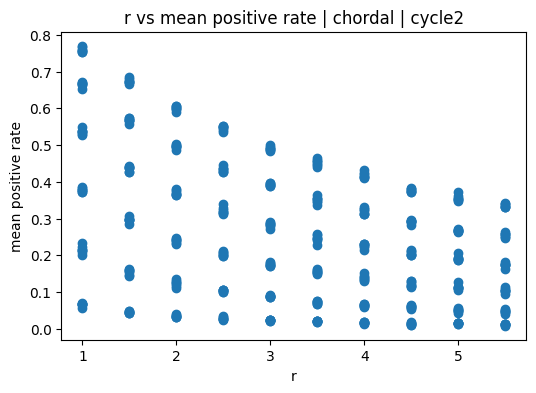

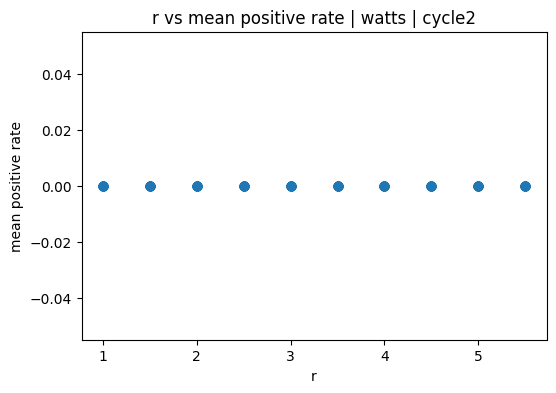

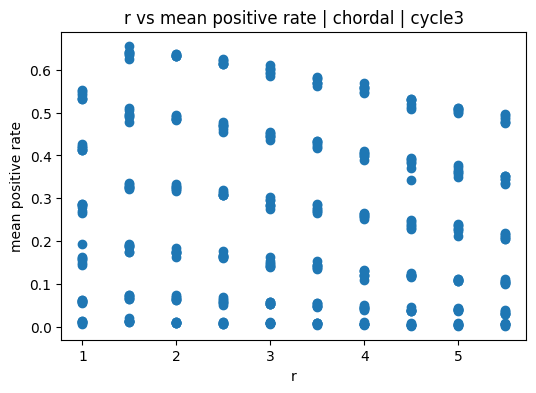

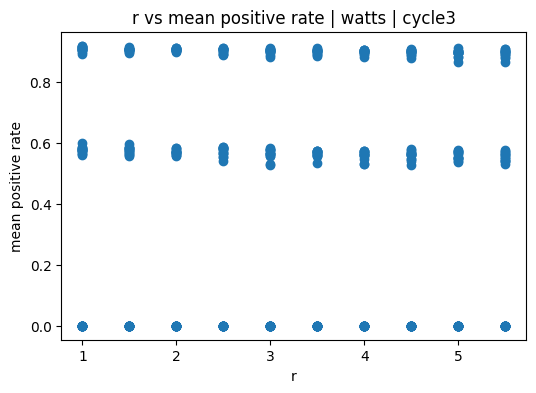

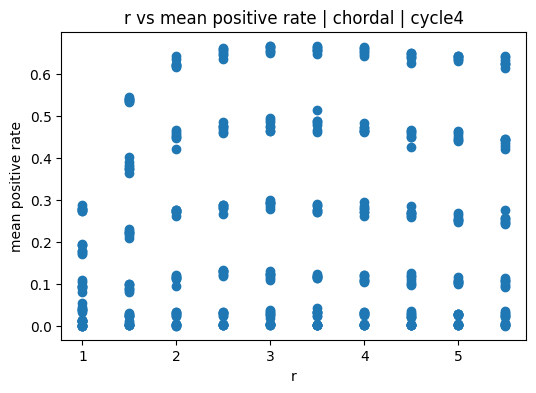

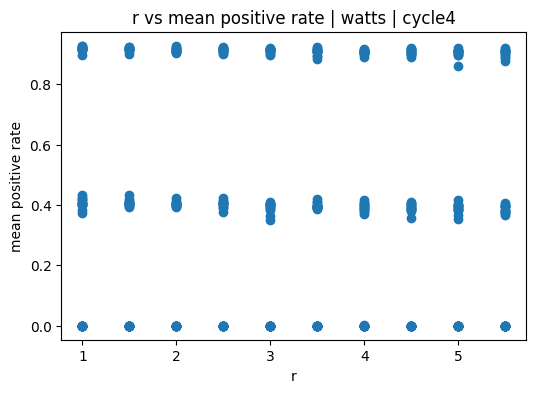

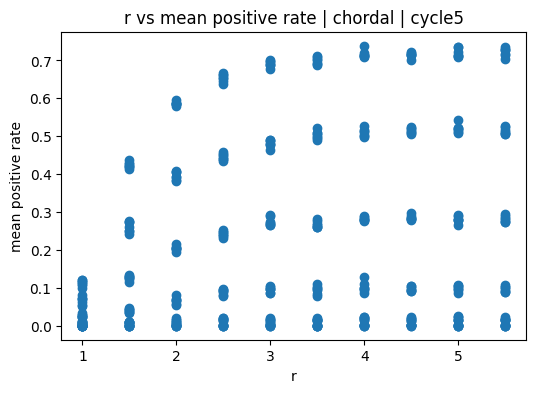

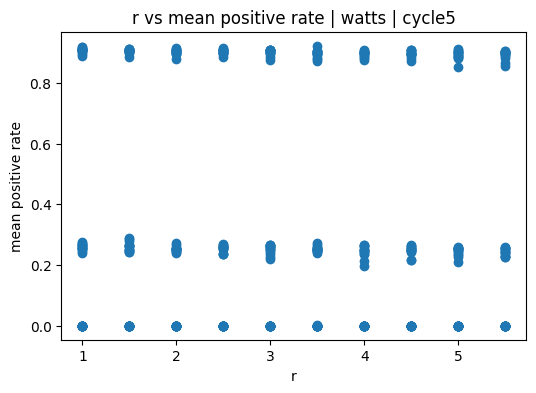

In [8]:
generators = sorted(df["type"].unique())
for task in tasks:
    col = f"{task}_pos_rate_mean"
    if col not in df.columns:
        continue
    for gen in generators:
        sub = df[df["type"] == gen].copy()
        if sub.empty:
            continue
        plt.figure(figsize=(6, 4))
        plt.scatter(sub["r"], sub[col])
        plt.title(f"r vs mean positive rate | {gen} | {task}")
        plt.xlabel("r")
        plt.ylabel("mean positive rate")

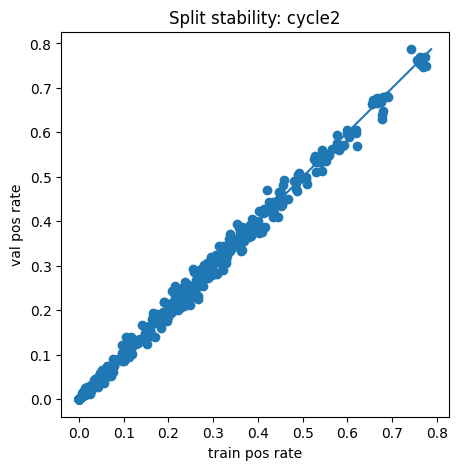

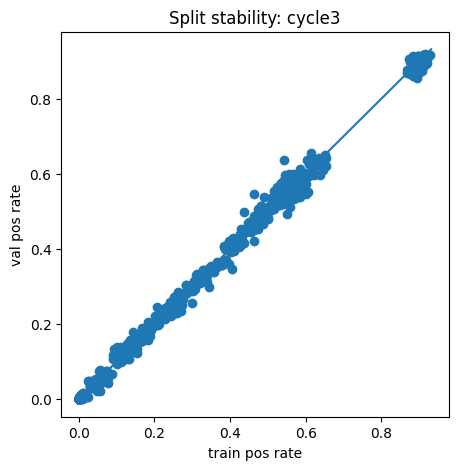

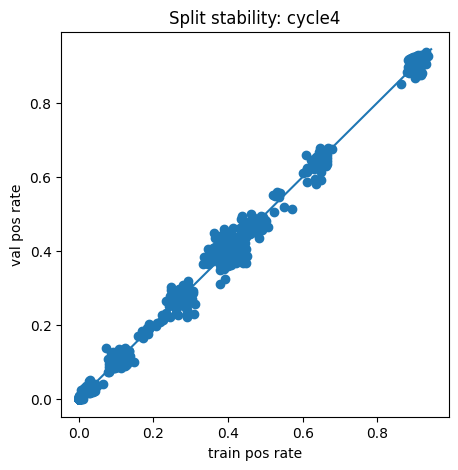

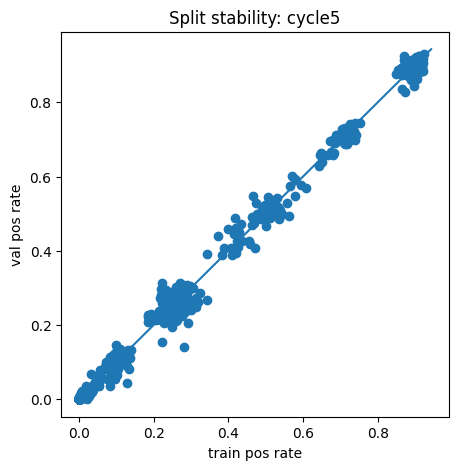

In [41]:
for task in tasks:
    cols = [f"{split_name}_{task}_pos_rate" for split_name in ["train", "val", "test"]]
    if not all(c in df.columns for c in cols):
        continue
    x = df[cols[0]].values
    y = df[cols[1]].values
    z = df[cols[2]].values
    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, label="train vs val")
    lim = [0, max(np.nanmax(x), np.nanmax(y), np.nanmax(z), 0.01)]
    plt.plot(lim, lim)
    plt.xlabel("train pos rate")
    plt.ylabel("val pos rate")
    plt.title(f"Split stability: {task}")
    save_path = PLOTS_ROOT / f"Split_stability_val_{task}_pos_rate.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

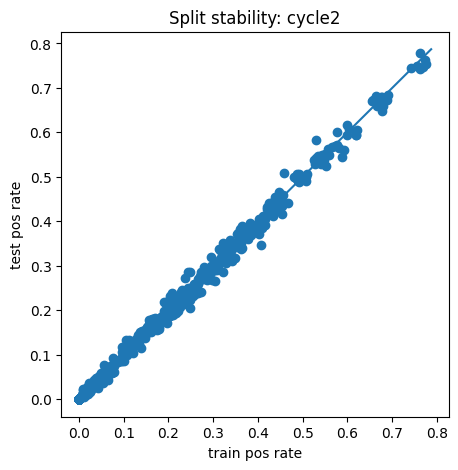

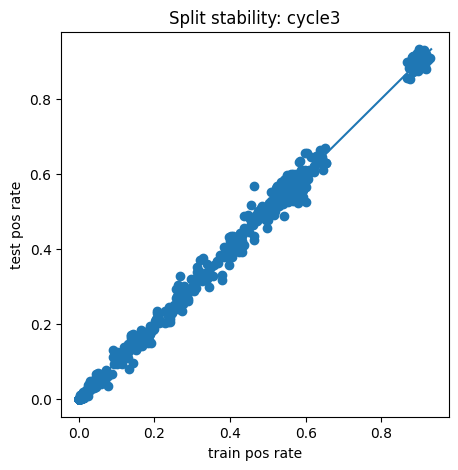

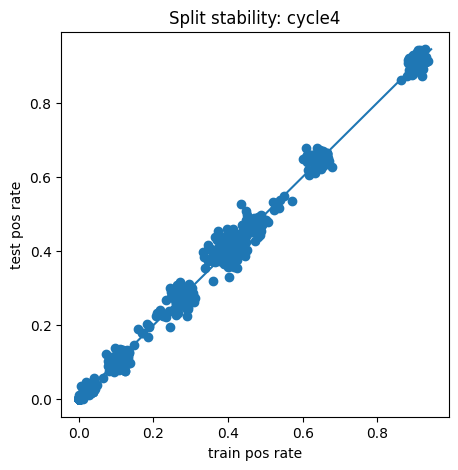

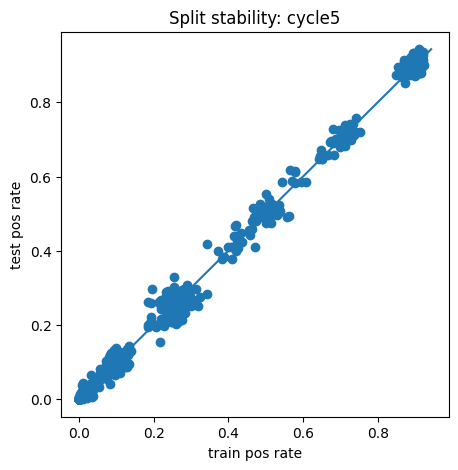

In [42]:
for task in tasks:
    cols = [f"{split_name}_{task}_pos_rate" for split_name in ["train", "val", "test"]]
    if not all(c in df.columns for c in cols):
        continue
    x = df[cols[0]].values
    y = df[cols[1]].values
    z = df[cols[2]].values
    plt.figure(figsize=(5, 5))
    plt.scatter(x, z, label="train vs test")
    lim = [0, max(np.nanmax(x), np.nanmax(y), np.nanmax(z), 0.01)]
    plt.plot(lim, lim)
    plt.xlabel("train pos rate")
    plt.ylabel("test pos rate")
    plt.title(f"Split stability: {task}")
    save_path = PLOTS_ROOT / f"Split_stability_test_{task}_pos_rate.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

In [43]:
def show_selected_overview(selected, tasks):
    if isinstance(selected, pd.DataFrame):
        row = selected.iloc[0]
    else:
        row = selected

    meta_cols = ["graph_id", "dataset_id", "type", "selected_profile"]
    for col in meta_cols:
        print(f"{col}: ", row[col])

    records = []
    for task in tasks:

        rec = {
            "task": task,
            "pos_rate_mean": row.get(f"{task}_pos_rate_mean", pd.NA),
            "pos_rate_max_diff_from_mean": row.get(
                f"{task}_pos_rate_max_diff_from_mean", pd.NA
            ),
            "pos_nodes_mean": row.get(f"{task}_pos_nodes_mean", pd.NA),
            "pos_nodes_max_diff_from_mean": row.get(
                f"{task}_pos_nodes_max_diff_from_mean", pd.NA
            ),
        }
        records.append(rec)

    overview = pd.DataFrame(records)

    for c in [
        "pos_rate_mean",
        "pos_rate_max_diff_from_mean",
        "pos_nodes_mean",
        "pos_nodes_max_diff_from_mean",
    ]:
        if c in overview.columns:
            overview[c] = pd.to_numeric(overview[c], errors="coerce").round(3)

    display(overview)
    print("\n")
    return overview

In [ ]:
profiles = {
    "increasing": np.array([0.25, 0.40, 0.55, 0.70], dtype=float),
    "flat": np.array([0.70, 0.70, 0.70, 0.70], dtype=float),
    "decreasing": np.array([0.70, 0.55, 0.40, 0.25], dtype=float),
}

# require positive nodes in all splits for all tasks
pos_conditions = []
for task in tasks:    
    pos_conditions.append(df[f"{task}_all_splits_have_pos"])

df["all_splits_have_pos"] = np.logical_and.reduce(pos_conditions)

pos_nodes_cols = []
mean_rate_cols = []
max_diff_mean_rate_cols = []

for task in tasks:
    pos_nodes_cols.append(f"{task}_pos_nodes_mean")
    pos_nodes_cols.append(f"{task}_pos_nodes_max_diff_from_mean")

    mean_rate_cols.append(f"{task}_pos_rate_mean")
    max_diff_mean_rate_cols.append(f"{task}_pos_rate_max_diff_from_mean")

# only keep rows with positives everywhere
valid = df[df["all_splits_have_pos"]].copy()
# valid = valid[valid["train_num_nodes"] >= 4000]
print(len(valid))

# add MAE columns
for profile_name, target in profiles.items():
    valid[f"mae_{profile_name}"] = valid[mean_rate_cols].apply(
        lambda row: np.mean(np.abs(row.values.astype(float) - target)),
        axis=1,
    )

selected_parts = []
for profile_name in profiles:
    sub = valid.sort_values(f"mae_{profile_name}", ascending=True).head(1).copy()
    sub["selected_profile"] = profile_name
    selected_parts.append(sub)

for selected in selected_parts:
    show_selected_overview(selected, TASKS)

selected_df = pd.concat(selected_parts, ignore_index=True)
selected_df.to_csv("training_selected_graphs.csv", index=False)

342
graph_id:  751
dataset_id:  data_2500_6_5.5_chordal
type:  chordal
selected_profile:  increasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.331,0.020,826.333,50.333
1,cycle3,0.478,0.023,1195.000,58.000
2,cycle4,0.613,0.019,1533.333,48.667
3,cycle5,0.704,0.012,1759.333,30.333




graph_id:  108
dataset_id:  data_2000_6_2.5_chordal
type:  chordal
selected_profile:  flat


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.541,0.007,1082.667,14.333
1,cycle3,0.623,0.024,1245.333,48.667
2,cycle4,0.660,0.009,1321.000,19.000
3,cycle5,0.662,0.013,1323.333,25.333




graph_id:  623
dataset_id:  data_1500_5_1.5_chordal
type:  chordal
selected_profile:  decreasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.575,0.017,862.000,25.000
1,cycle3,0.512,0.010,768.333,15.333
2,cycle4,0.390,0.016,585.333,23.333
3,cycle5,0.243,0.026,364.000,39.000
